# dsPCA demo — Visual-cortex stimulus subspaces

This notebook applies **demixed subspace PCA (dsPCA)** to a GtdKO + AAV-Gαt2 (post-training) primary visual cortex (V1) **pseudopopulation** responding to drifting-grating stimuli (6 orientations × 6 spatial frequencies). It reproduces the population-geometry panels of Cao et al. (Fig. 6):

* **Panel B** — projection of the population onto the **stimulus-coding** subspace (orientation + spatial-frequency axes) and the orthogonal **stimulus-null** subspace.
* **Panel C** — the orientation geometry in the `[sin(2θ), cos(2θ)]` coding plane, one plot per spatial frequency.
* **Panel D** — the mean distance between adjacent orientations as a function of spatial frequency (a scalar read-out of orientation discriminability).

The example data (`vision_GtdKO_pseudopopulation.npz`) is the exact pseudopopulation used in the GtdKO + AAV-Gαt2 (post-training) row of Fig. 6B: V1 neurons pooled across the rescued mice (up to 80 neurons/mouse), trial-averaged, z-scored responses for each of 42 stimulus conditions (6 orientations × 7 spatial-frequency levels, where the first SF level per orientation is the 0-cpd blank/baseline).

## 1. Load modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3-D projection)

from dspca.dspca import dsPCA

np.set_printoptions(precision=3, suppress=True)

## 2. Load the pseudopopulation

`condition_means` has shape `(n_conditions, n_neurons)` — dsPCA treats each **condition** (row) as an observation and each **neuron** (column) as a feature. Condition ordering is orientation-major, SF-minor; `condition_spatial_freq_cpd == 0` marks the blank/baseline. The `.npz` ships in the repo's `data/` folder; run this notebook from its `demo/` location (the default Jupyter working directory) so the relative path resolves.

In [2]:
# data lives in the repo's data/ folder; path is relative to this notebook (in demo/)
D = np.load('../data/vision_GtdKO_pseudopopulation.npz', allow_pickle=True)
condition_means = D['condition_means'].astype(float)          # (42 conditions, N neurons)
ori_deg = D['condition_orientation_deg'].astype(float)        # orientation of each condition
sf_cpd  = D['condition_spatial_freq_cpd'].astype(float)       # spatial freq (0 = blank)

n_cond, n_neuron = condition_means.shape
print(f'{n_cond} conditions x {n_neuron} neurons')
print('orientations (deg):', np.unique(ori_deg))
print('spatial frequencies (cpd, 0 = blank):', np.unique(sf_cpd))

42 conditions x 347 neurons
orientations (deg): [  0.  30.  60.  90. 120. 150.]
spatial frequencies (cpd, 0 = blank): [0.   0.02 0.04 0.08 0.16 0.32 0.64]


## 3. Define the stimulus (target) variables

dsPCA finds the neural axes that best explain a set of **target** variables. Here the targets describe the stimulus of each condition:

* **spatial frequency** — z-scored `log2(SF)` over the real (SF > 0) levels; the blank is set to 0;
* **orientation** — encoded as `sin(2θ)` and `cos(2θ)` to respect the 180° periodicity of grating orientation.

Each target column is standardized before fitting.

In [3]:
real = sf_cpd > 0
log2sf = np.zeros_like(sf_cpd)
log2sf[real] = np.log2(sf_cpd[real])
mu, sd = log2sf[real].mean(), log2sf[real].std()
sf_code = np.where(real, (log2sf - mu) / sd, 0.0)

theta = np.deg2rad(2 * ori_deg)
targets_raw = np.column_stack([sf_code, np.sin(theta), np.cos(theta)])
targets = (targets_raw - targets_raw.mean(0)) / targets_raw.std(0)
print('targets shape:', targets.shape, '-> columns = [SF, sin(2theta), cos(2theta)]')

targets shape: (42, 3) -> columns = [SF, sin(2theta), cos(2theta)]


## 4. Run dsPCA

`dsPCA` returns (in order): the projections onto the target and target-free subspaces, the axis vectors, the target/target-free signal correlations, the variance captured by each axis, the total variance, and the axis-orthogonality matrix.

In [4]:
(projection_target_subspace, projection_targetfree_subspace,
 ax_targets, ax_targetfree,
 target_subspace_signal, targetfree_subspace_signal,
 target_subspace_var, targetfree_subspace_var,
 total_var, dot_target_ax) = dsPCA(data=condition_means, targets=targets)

sf_pct  = 100 * target_subspace_var[0] / total_var
ori_pct = 100 * np.hypot(target_subspace_var[1], target_subspace_var[2]) / total_var
print(f'stimulus-coding variance: orientation = {ori_pct:.1f}%, spatial frequency = {sf_pct:.1f}% of total')
print('axis orthogonality (max |off-diagonal| of dot_target_ax):',
      float(np.max(np.abs(dot_target_ax - np.eye(3)))))

Trial number 42 is smaller than (Dimension - # of targets) of 344
# of dimensions for target-free subspace is set to the trial number 42
stimulus-coding variance: orientation = 10.8%, spatial frequency = 30.6% of total
axis orthogonality (max |off-diagonal| of dot_target_ax): 0.23864394856940588


## 5. Variance explained by each axis

The three stimulus-coding axes (SF, sin2θ, cos2θ) versus the leading stimulus-null (target-free) axes, as a percentage of the total population variance.

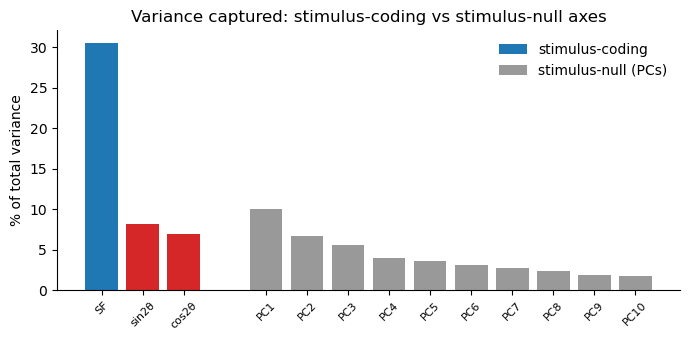

In [5]:
coding_pct = 100 * np.asarray(target_subspace_var[:3]) / total_var
null_pct   = 100 * np.asarray(targetfree_subspace_var[:10]) / total_var

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(np.arange(3), coding_pct, color=['#1f77b4', '#d62728', '#d62728'], label='stimulus-coding')
ax.bar(np.arange(10) + 4, null_pct, color='0.6', label='stimulus-null (PCs)')
ax.set_xticks(list(range(3)) + list(range(4, 14)))
ax.set_xticklabels(['SF', 'sin2θ', 'cos2θ'] + [f'PC{i+1}' for i in range(10)], rotation=45, fontsize=8)
ax.set_ylabel('% of total variance'); ax.legend(frameon=False)
ax.set_title('Variance captured: stimulus-coding vs stimulus-null axes')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Panel B — stimulus-coding and stimulus-null subspaces

Each point is one stimulus condition, **colored by orientation** and **sized by spatial frequency**; points of the same SF are connected. In the **coding** subspace the population forms a structured, cone-like geometry (orientation resolved on the `sin2θ/cos2θ` plane, SF along the third axis); in the orthogonal **stimulus-null** subspace no systematic stimulus structure remains. (Null-axis percentages are variance relative to the total.)

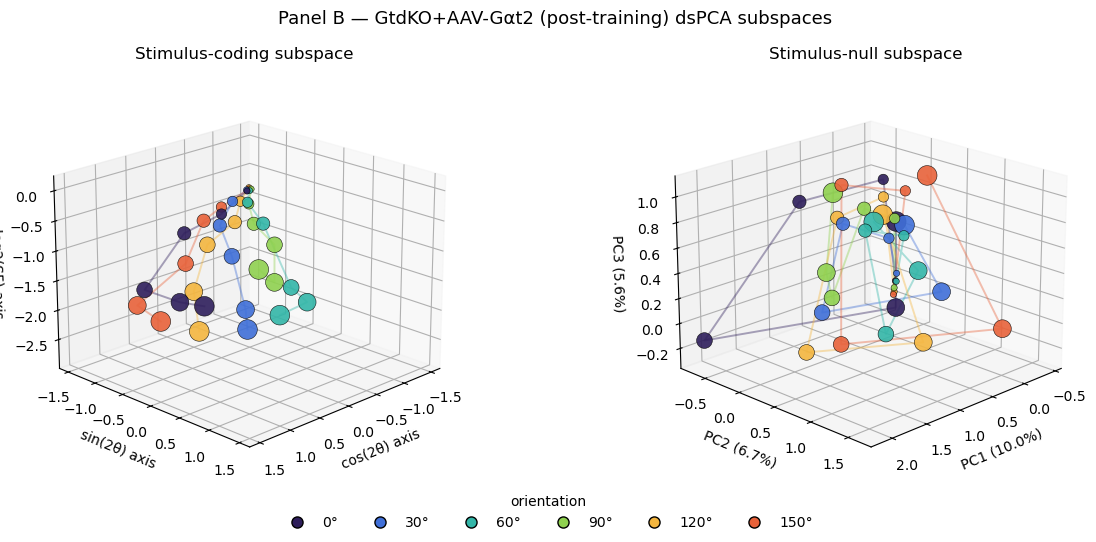

In [6]:
ORI = np.array([0, 30, 60, 90, 120, 150.])
SF  = np.array([0.02, 0.04, 0.08, 0.16, 0.32, 0.64])
ori_colors = {0:'#2e1e5b', 30:'#3f6fd8', 60:'#33b6a8', 90:'#8fd14f', 120:'#f4b63f', 150:'#e8623a'}

# categorical marker sizes: LOW SF = large, HIGH SF = small (as in the Fig 6B legend)
_SF_SIZES = dict(zip(SF, np.linspace(200, 20, len(SF))))
def sf_size(s):
    return _SF_SIZES[min(SF, key=lambda x: abs(x - s))]

def plot_subspace_3d(ax, coords, xi, yi, zi, labels, title, lims=None, azim=45):
    # connect points of the SAME orientation across spatial frequencies (colored spokes),
    # as in Fig 6B; markers are sized by spatial frequency (low SF = large).
    for o in ORI:
        idx = np.where(real & (np.abs(ori_deg - o) < 1e-6))[0]
        idx = idx[np.argsort(sf_cpd[idx])]
        c = ori_colors[int(round(o))]
        ax.plot(coords[idx, xi], coords[idx, yi], coords[idx, zi], color=c, lw=1.4, alpha=0.4)
        ax.scatter(coords[idx, xi], coords[idx, yi], coords[idx, zi], color=c,
                   s=[sf_size(s) for s in sf_cpd[idx]], edgecolor='k', linewidth=0.4,
                   alpha=0.9, depthshade=False)
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1]); ax.set_zlabel(labels[2])
    ax.set_title(title); ax.view_init(elev=20, azim=azim)
    if lims is not None:
        ax.set_xlim(*lims); ax.set_ylim(*lims)

null_pct3 = 100 * targetfree_subspace_var[:3] / total_var
fig = plt.figure(figsize=(13, 5.4))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plot_subspace_3d(ax1, projection_target_subspace, 2, 1, 0,
                 ['cos(2θ) axis', 'sin(2θ) axis', 'log2(SF) axis'], 'Stimulus-coding subspace',
                 lims=(-1.6, 1.6), azim=45)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plot_subspace_3d(ax2, projection_targetfree_subspace[:, :3], 0, 1, 2,
                 [f'PC1 ({null_pct3[0]:.1f}%)', f'PC2 ({null_pct3[1]:.1f}%)', f'PC3 ({null_pct3[2]:.1f}%)'],
                 'Stimulus-null subspace')

handles = [plt.Line2D([0], [0], marker='o', ls='', mfc=c, mec='k', ms=8, label=f'{int(o)}°')
           for o, c in ori_colors.items()]
fig.legend(handles=handles, title='orientation', loc='lower center', ncol=6, frameon=False)
fig.suptitle('Panel B — GtdKO+AAV-Gαt2 (post-training) dsPCA subspaces', fontsize=13)
plt.tight_layout(rect=[0, 0.06, 1, 1]); plt.show()

## 7. Panel C — orientation geometry per spatial frequency

The six orientation conditions of each spatial frequency, plotted in the coding-subspace orientation plane `[sin(2θ), cos(2θ)]` and centered on their common center of mass. The orientation polygon is large at low-to-intermediate SF and collapses toward the origin at high SF, where orientation is poorly resolved.

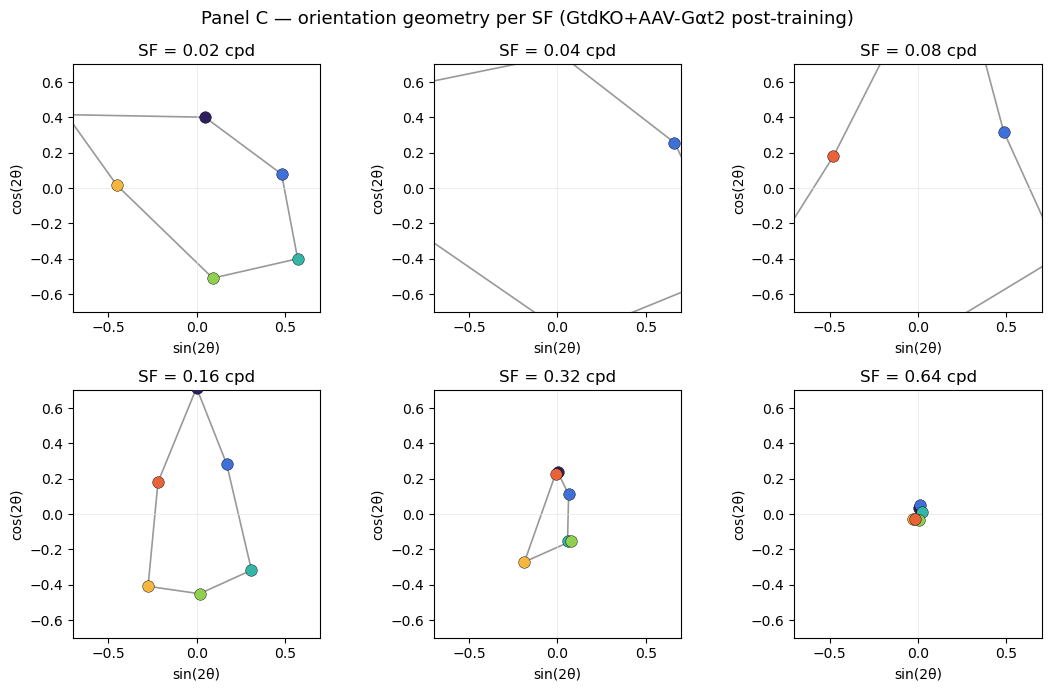

In [7]:
P = projection_target_subspace
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, s in zip(axes.ravel(), SF):
    idx = np.where(real & (np.abs(sf_cpd - s) < 1e-6))[0]
    idx = idx[np.argsort(ori_deg[idx])]
    pts = P[idx][:, [1, 2]] - P[idx][:, [1, 2]].mean(0)   # sin,cos; center of mass removed
    loop = np.vstack([pts, pts[:1]])
    ax.plot(loop[:, 0], loop[:, 1], color='0.6', lw=1.2, zorder=1)
    for k, j in enumerate(idx):
        ax.scatter(pts[k, 0], pts[k, 1], color=ori_colors[int(round(ori_deg[j]))],
                   s=70, edgecolor='k', linewidth=0.3, zorder=3)
    ax.set_title(f'SF = {s:g} cpd'); ax.set_xlabel('sin(2θ)'); ax.set_ylabel('cos(2θ)')
    ax.set_aspect('equal'); ax.set_xlim(-0.7, 0.7); ax.set_ylim(-0.7, 0.7)
    ax.axhline(0, color='0.9', lw=0.5); ax.axvline(0, color='0.9', lw=0.5)
fig.suptitle('Panel C — orientation geometry per SF (GtdKO+AAV-Gαt2 post-training)', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Panel D — adjacent-orientation distance vs spatial frequency

A scalar summary of orientation discriminability: the mean Euclidean distance between population states of adjacent orientations (30° apart) in the coding-subspace orientation plane, computed for each spatial frequency.

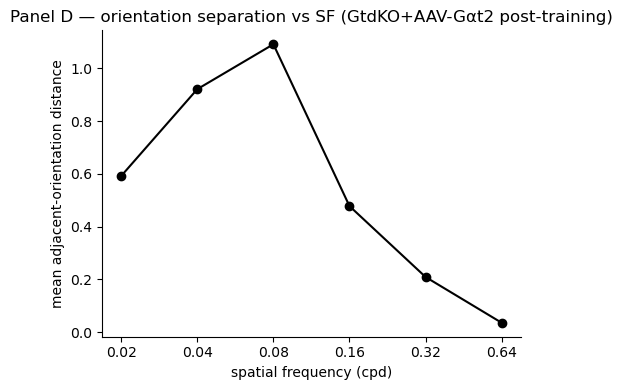

In [8]:
def adjacent_distance(sf_target):
    idx = np.where(real & (np.abs(sf_cpd - sf_target) < 1e-6))[0]
    idx = idx[np.argsort(ori_deg[idx])]
    pts = P[idx][:, [1, 2]] - P[idx][:, [1, 2]].mean(0)
    return float(np.mean(np.linalg.norm(pts - np.roll(pts, -1, axis=0), axis=1)))

adj = np.array([adjacent_distance(s) for s in SF])
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(range(len(SF)), adj, '-o', color='k', ms=6)
ax.set_xticks(range(len(SF))); ax.set_xticklabels([f'{s:g}' for s in SF])
ax.set_xlabel('spatial frequency (cpd)'); ax.set_ylabel('mean adjacent-orientation distance')
ax.set_title('Panel D — orientation separation vs SF (GtdKO+AAV-Gαt2 post-training)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
**Notes.** This demo uses a single (post-training rescued) pseudopopulation, so Panels C/D are shown without the across-mouse error shading of the manuscript figure. The stimulus-null percentages are reported as variance relative to the total population variance. To compare experimental groups (e.g. rescued pre- vs post-training), repeat steps 2–8 with each group's pseudopopulation and overlay Panels C/D.

Reference: Cao et al., *Restoration of behavioral vision …* (dsPCA method: Hattori & Komiyama, 2022).